# Specialist Training Research Workbench

This notebook is the inspection and experiment-control surface for electric guitar, strings, and wind/brass. The version-controlled Python scripts and YAML files remain authoritative. Paid cloud actions are never launched unless their `SUBMIT_*` guard is explicitly changed to `True`.

In [1]:
from pathlib import Path
import sys

search_root = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        candidate
        for candidate in (search_root, *search_root.parents)
        if (candidate / "workers/specialist_training_modal.py").is_file()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Repository root could not be located")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Audio, display

from research.workbench import (
    BASE_IDS,
    build_modal_command,
    display_command,
    experiment_snapshot,
    find_metric_json,
    load_index_manifest,
    local_listening_examples,
    modal_volume_paths,
    source_coverage,
    submit_modal_command,
    summarize_indexes,
)

sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.max_colwidth", 120)
PROJECT_ROOT

PosixPath('/home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server')

## 1. Dataset contract

Confirm the exact indexed population before acquisition or training. Duplicate hashes are reported because the same audio must not silently inflate a target family.

In [2]:
manifest = load_index_manifest()
index_summary = summarize_indexes()
display(index_summary)
print("Method:", manifest["method"])
print("Segment seconds:", manifest["segment_seconds"])
print("Profile:", manifest["profile"])

,rows,targets,interference,sources,compositions,duplicate_audio_hashes
base_id,,,,,,
electric_guitar,33990,10542,23448,11,13178,0
strings,33990,11868,22122,11,13178,0
wind_brass,33990,11424,22566,11,13178,0


Method: on_the_fly_random_stem_mixing
Segment seconds: 10
Profile: research_all


instrum,electric_guitar,other
source_id,,
albumdb,51,160
chorale_bricks,0,158
cocochorales,0,20000
eg_ipt,8628,0
guitar_techs,208,0
medleydb_sample,0,2
quartset,0,424
rawstems,1655,318
spheres,0,29


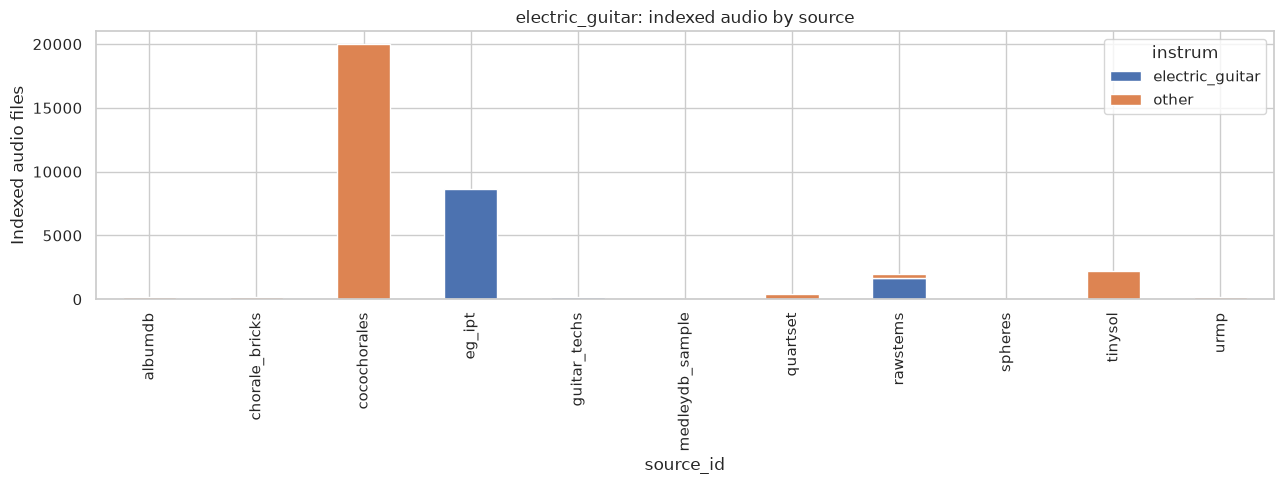

In [3]:
family = "electric_guitar"
coverage = source_coverage(family)
display(coverage)
ax = coverage.plot(kind="bar", stacked=True, figsize=(13, 5), title=f"{family}: indexed audio by source")
ax.set_ylabel("Indexed audio files")
plt.tight_layout()
plt.show()

## 2. Local listening review

These are earlier local candidate/reference exports. They are useful for checking the playback workflow, but they are not evidence that the new three-model training has passed.

In [4]:
examples = local_listening_examples(profile="clean-candidate-v1")
display(examples.head(20))

if not examples.empty:
    selected_audio = examples.iloc[0]["path"]
    print(selected_audio)
    display(Audio(filename=selected_audio))

,path,sample_rate,frames,channels,duration_seconds
0,/home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/training/listening/clean-candidate-v1/electr...,44100,588800,2,13.351
1,/home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/training/listening/clean-candidate-v1/electr...,44100,588800,2,13.351
2,/home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/training/listening/clean-candidate-v1/electr...,44100,588800,2,13.351
3,/home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/training/listening/clean-candidate-v1/electr...,44100,588800,2,13.351
4,/home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/training/listening/clean-candidate-v1/electr...,44100,588800,2,13.351
5,/home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/training/listening/clean-candidate-v1/electr...,44100,588800,2,13.351
6,/home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/training/listening/clean-candidate-v1/electr...,44100,588800,2,13.351
7,/home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/training/listening/clean-candidate-v1/electr...,44100,588800,2,13.351
8,/home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/training/listening/clean-candidate-v1/electr...,44100,588800,2,13.351
9,/home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/training/listening/clean-candidate-v1/string...,44100,396900,2,9.000


/home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/training/listening/clean-candidate-v1/electric_guitar/008e36cd5f14d62209e4740f50f3db65755dc71c412b4f32ff45148470253c56/electric_guitar.flac


## 3. Modal data status

A source receipt means its acquisition committed to the persistent Modal volume. It does not mean the complete index has been materialized.

In [5]:
try:
    source_receipts = modal_volume_paths("/source_receipts")
    display(pd.DataFrame({"committed_source_receipt": source_receipts}))
except Exception as error:
    print(f"Modal status unavailable: {error}")

,committed_source_receipt
0,source_receipts/rawstems
1,source_receipts/albumdb


## 4. Resume cloud acquisition

Modal's asynchronous submission returns a persistent function-call ID immediately, so acquisition keeps running if this notebook, terminal, or network connection disappears. Review the command first. Change the guard only when ready.

In [6]:
prepare_command = build_modal_command(action="prepare")
print(display_command(prepare_command))

SUBMIT_PREPARE = False
if SUBMIT_PREPARE:
    launch_receipt = submit_modal_command(
        prepare_command,
        confirm=True,
    )
    display(launch_receipt)

/home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/.venvs/gpu-worker/bin/modal run --detach /home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/workers/specialist_training_modal.py --base-id electric_guitar --action prepare --run-id research-run --dataset-id complete-source-pools


## 5. Reproducible training submission

Each target gets an independent BS-RoFormer checkpoint. The snapshot records the Git commit, dirty-worktree state, indexed-data hash, run ID, and exact detached command before any GPU is allocated.

In [7]:
RUN_ID = "specialists-20260727"
STEPS = 200_000
EPOCHS = 1

training_commands = {}
for base_id in BASE_IDS:
    snapshot = experiment_snapshot(
        run_id=RUN_ID,
        base_id=base_id,
        steps=STEPS,
        epochs=EPOCHS,
    )
    training_commands[base_id] = build_modal_command(
        action="train",
        base_id=base_id,
        run_id=RUN_ID,
        steps=STEPS,
        epochs=EPOCHS,
    )
    print(base_id, snapshot["index_sha256"])
    print(" ", snapshot["command"])

SUBMIT_TRAINING = False
if SUBMIT_TRAINING:
    launches = {
        base_id: submit_modal_command(
            command,
            confirm=True,
        )
        for base_id, command in training_commands.items()
    }
    display(pd.DataFrame(launches).T)

electric_guitar a6a91d305b78df9dccbe54f9b8f9902c036aad2056c3b853c567019ffbabde66
  /home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/.venvs/gpu-worker/bin/modal run --detach /home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/workers/specialist_training_modal.py --base-id electric_guitar --action train --run-id specialists-20260727 --dataset-id complete-source-pools --steps 200000 --epochs 1
strings fca9d37ee2b825761b033015561ed3d3fd8bab3c88c6a348e28ff824feeac013
  /home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/.venvs/gpu-worker/bin/modal run --detach /home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation-Server/workers/specialist_training_modal.py --base-id strings --action train --run-id specialists-20260727 --dataset-id complete-source-pools --steps 200000 --epochs 1
wind_brass ad557dff6e29dcda3cd3ff4ba95417958d3831b42bcc22766c3ea951b8238de3
  /home/ayodele/Desktop/marlon-music/StemSplitter-Audio-Separation

## 6. Result discovery

After checkpoints and exports are downloaded, use this section to discover receipts/scorecards and compare predicted audio with its held-out reference. No model is promoted from file existence alone.

In [8]:
metric_files = find_metric_json()
display(pd.DataFrame({"metric_or_receipt": [str(path.relative_to(PROJECT_ROOT)) for path in metric_files]}).tail(50))

,metric_or_receipt
74,training/rendered/sprint-v1/artifacts/strings/020cb47067219560a588046d163aaf0bef280ad8ba83d8f2e41af8962edc5722/recei...
75,training/rendered/sprint-v1/artifacts/strings/022115c3e397c7ca4cabc949351d5a63b95ae00131692c41c7e091e5e0de0ff6/recei...
76,training/rendered/sprint-v1/artifacts/strings/025a1b982da3bb9ce79f5f77d185b0d824c85053e2f98f80ec9c57c7f9c8f1cc/recei...
77,training/rendered/sprint-v1/artifacts/strings/026bc27bedf8a015b411b5ea1e50b595913927b344a82e5c40b0ff4616f73479/recei...
78,training/rendered/sprint-v1/artifacts/strings/0288fca4216988058b6728ff964538209d809d67533348afcee8bc7b17df5e24/recei...
79,training/rendered/sprint-v1/artifacts/strings/02e170b194cb6d3c9f32bdfc8b88b4f33021137ed4f5a63b0bbed5b4b6b1e85a/recei...
80,training/rendered/sprint-v1/artifacts/strings/03125f6d43f0a89eea4dffd91d13660470b7f89be3c3f0bec26851f6221dcf84/recei...
81,training/rendered/sprint-v1/artifacts/strings/0313576f093208f14404a64c35f9e576b822cbfd9abc773a3eea8d0007e00f5c/recei...
82,training/rendered/sprint-v1/artifacts/strings/033b4af3c047efb871232f1da17fc75c887fea7cf54f1b763b9615579e7e8db5/recei...
83,training/rendered/sprint-v1/artifacts/strings/0354804a7a82c3bd31fb4855203f81fc1ce1b03a62430f129ad5009c6a18f67d/recei...


## Research rule

A specialist checkpoint is accepted only after held-out objective evaluation and listening review. Dataset counts, successful training completion, or the existence of an audio file are not quality proof.